
## PROJE: Production Demand Forecasting & Capacity Planning Dashboard
Kaggle:
Store Item Demand Forecasting Challenge

İçerik: 10 farklı mağazada satılan 50 farklı ürünün 2013-2017 arası 5 yıllık günlük satış adetleri. Her satır bir "hangi tarihte, hangi mağazada, hangi üründen kaç adet satıldı" bilgisi.



1. Excel:	Veriyi düzenleme, temel analiz, sonuç tablosu
2. Python:	Veri temizleme, analiz, talep tahmini
3. SQL:	Üretim, sipariş, stok verilerini sorgulama	Sonradan ekleyebiliriz
4. Power BI:	Dashboard ve KPI'ları görselleştirme	Sonradan ekleyeceğiz

In [2]:
import pandas as pd

df = pd.read_csv('train.csv')
df['date'] = pd.to_datetime(df['date'])

df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [3]:
import matplotlib.pyplot as plt
#Genel bilgi
df.shape

(913000, 4)

In [4]:
df.isnull().sum()    #Boş değer yok

,0
date,0
store,0
item,0
sales,0


In [5]:
df['store'].nunique()

10

In [6]:
df['item'].nunique()

50

In [7]:
print(f'{df['date'].min()} ,  {df['date'].max()}')

2013-01-01 00:00:00 ,  2017-12-31 00:00:00


<Axes: title={'center': 'Toplam Günlük Satış'}, xlabel='date'>

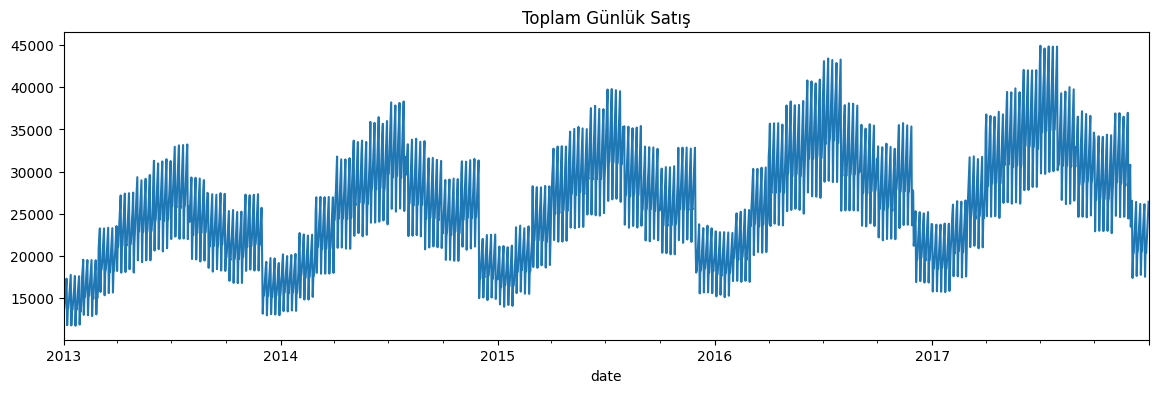

In [8]:
#Toplam günlük satış adedi
daily_sales = df.groupby('date')['sales'].sum()
daily_sales.plot(figsize = (14,4), title = 'Toplam Günlük Satış')

Grafiğe göre:
1. her yaz (Haziran-Ağustos) satışlar zirve yapıyor, kış aylarında (Ocak-Şubat) dip yapıyor. Mevsimsellik var.

2. her yılın zirvesi bir önceki yıldan yüksek. Büyüme var.

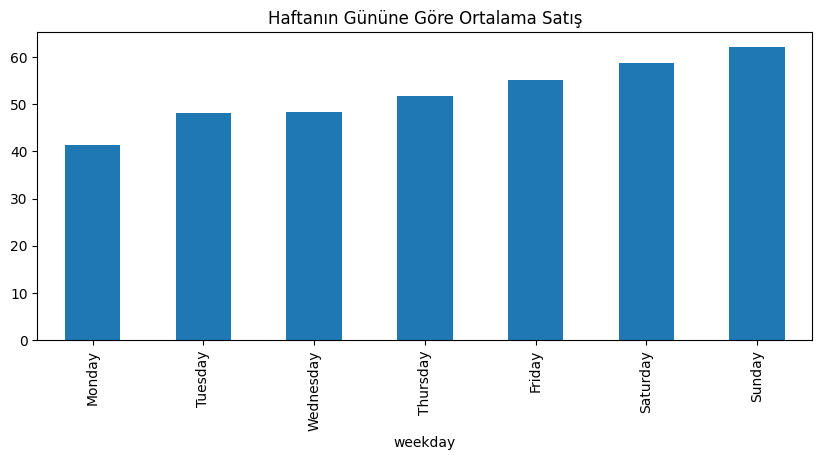

In [9]:
#Haftalık desene bakalım
df['weekday'] = df['date'].dt.day_name()
weekday_avg = df.groupby('weekday')['sales'].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

weekday_avg.plot(kind = 'bar', figsize = (10,4), title = 'Haftanın Gününe Göre Ortalama Satış')
plt.show()

yıllık mevsimsellik + artan trend + haftalık döngü

In [10]:
#Tarih bazlı özellikler
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek #0 = Pazartesi
df['weekofyear'] = df['date'].dt.isocalendar().week

# Lag ve rolling özellikler (her store-item kombinasyonu için ayrı ayrı, sıralı)
#lag_7 / lag_28: 7 ve 28 gün önceki satış (geçen hafta/geçen ay bugün ne satmış)
#rolling_mean_7: son 7 günün hareketli ortalaması (kısa vadeli trend)

df = df.sort_values(['store', 'item', 'date'])
df['lag_7'] = df.groupby(['store', 'item'])['sales'].shift(7)
df['lag_28'] = df.groupby(['store', 'item'])['sales'].shift(28)

df['rolling_mean_7'] = df.groupby(['store', 'item'])['sales'].transform(lambda x: x.shift(1).rolling(7).mean())
df.head(30)

,date,store,item,sales,weekday,year,month,day,dayofweek,weekofyear,lag_7,lag_28,rolling_mean_7
0,2013-01-01,1,1,13,Tuesday,2013,1,1,1,1,NaN,NaN,NaN
1,2013-01-02,1,1,11,Wednesday,2013,1,2,2,1,NaN,NaN,NaN
2,2013-01-03,1,1,14,Thursday,2013,1,3,3,1,NaN,NaN,NaN
3,2013-01-04,1,1,13,Friday,2013,1,4,4,1,NaN,NaN,NaN
4,2013-01-05,1,1,10,Saturday,2013,1,5,5,1,NaN,NaN,NaN
5,2013-01-06,1,1,12,Sunday,2013,1,6,6,1,NaN,NaN,NaN
6,2013-01-07,1,1,10,Monday,2013,1,7,0,2,NaN,NaN,NaN
7,2013-01-08,1,1,9,Tuesday,2013,1,8,1,2,13.0,NaN,11.857143
8,2013-01-09,1,1,12,Wednesday,2013,1,9,2,2,11.0,NaN,11.285714
9,2013-01-10,1,1,9,Thursday,2013,1,10,3,2,14.0,NaN,11.428571


In [11]:
# NaN satırları at (lag/rolling nedeniyle oluşan)
df_model = df.dropna()

#Elimizdeki veriyi sonuçlarımızı test edebilmek için ikiye böldük. train ve test

# Son 3 ay (Ekim-Aralık 2017) test, geri kalanı train
split_date = '2017-10-01'
train = df_model[df_model['date'] < split_date]
test = df_model[df_model['date'] >= split_date]

print(train.shape, test.shape)

(853000, 13) (46000, 13)


## xgboost
XGBoost, karar ağaçlarını boosting yöntemiyle ardışık olarak oluşturan bir ensemble öğrenme algoritmasıdır. Her yeni ağaç, önceki modellerin hatalarını azaltmaya çalışarak nihai tahmin performansını geliştirir.

In [12]:
!pip install xgboost -q
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

features = ['store', 'item', 'year', 'month', 'day', 'dayofweek', 'weekofyear',  'lag_7', 'lag_28', 'rolling_mean_7']
target = 'sales'

x_train, y_train = train[features], train[target]
x_test, y_test = test[features], test[target]

model = xgb.XGBRegressor(
    n_estimators=500, # kaç tane ağaç kurulacak
    learning_rate=0.05, # her ağacın ne kadar "agresif" öğreneceği (küçük = yavaş ama stabil öğrenme)
    max_depth=6,        # her ağacın maksimum derinliği (karmaşıklığı)
    random_state=42      # tekrar çalıştırınca aynı sonucu almak için sabit tohum
)
model.fit(x_train, y_train)

preds = model.predict(x_test)
mae = mean_absolute_error(y_test, preds)
print(f"MAE: {mae:.2f}")

MAE: 6.10


In [13]:
baseline_mae = mean_absolute_error(y_test, test['lag_7'])
print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"XGBoost MAE: {mae:.2f}")

Baseline MAE: 9.08
XGBoost MAE: 6.10


Geçen haftanın aynı gününü doğrudan tahmin kabul eden baseline'ın MAE'si 9.8 iken, XGBoost'un MAE'si 6.10 oldu.

Modelin ortalama mutlak hatası yaklaşık 6.10 birimdir. Yani model, günlük satış miktarını ortalama olarak yaklaşık 6-7 adetlik hata ile tahmin etmektedir.

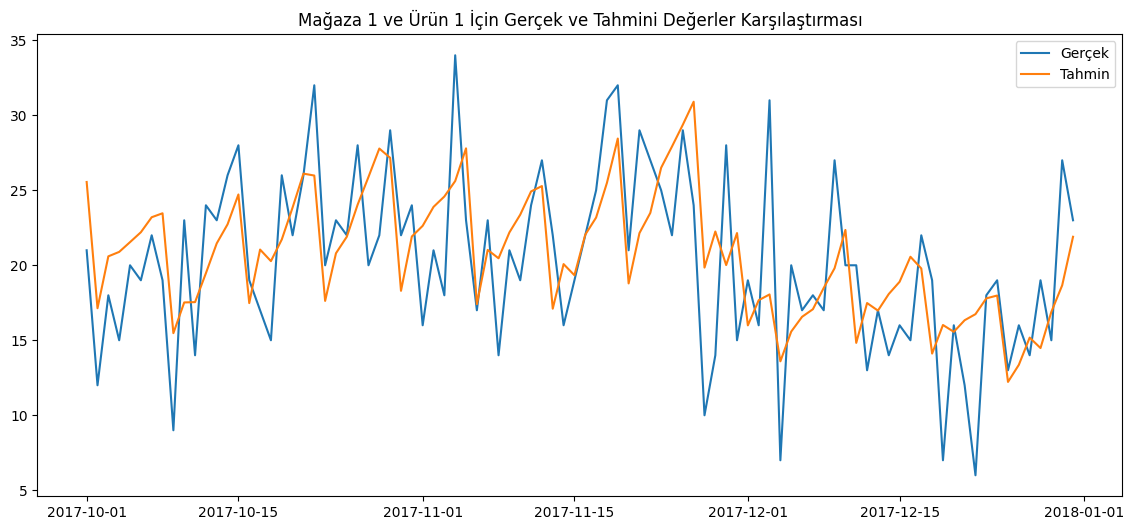

In [14]:
test_plot = test.copy()
test_plot['pred'] = preds

#Örnek olarak 1 mağaza ve 1 ürün seçip karşılaştıralım.
sample = test_plot[(test_plot['store'] == 1) & (test_plot['item'] == 1)].sort_values('date')

plt.figure(figsize =(14,6))
plt.plot(sample['date'], sample['sales'], label = 'Gerçek')
plt.plot(sample['date'], sample['pred'], label = 'Tahmin')
plt.legend()
plt.title('Mağaza 1 ve Ürün 1 İçin Gerçek ve Tahmini Değerler Karşılaştırması')
plt.show()

ani sıçramaları (örn. 7 Aralık'taki 31'lik zirve, ya da 22 Aralık'taki 6'lık dip) yakalayamadı, ortalamaya yakın tahmin etti. Bu XGBoost'un doğası gereği tekil rastgele dalgalanmaları değil, genel deseni öğreniyor. (7 günlük ortalama gibi verilerle çalıştığı için doğal olarak yumuşatıyor).

Mevsimsel eğilimleri doğru yakalamış. Kasım ortasındaki artış vs.

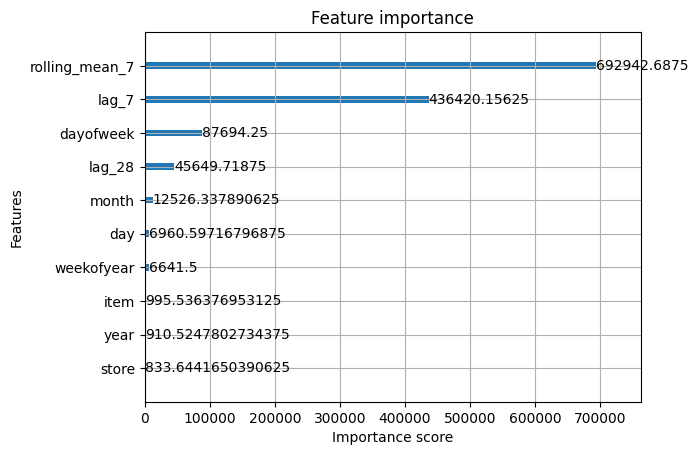

In [15]:
xgb.plot_importance(model, importance_type='gain')
plt.show()

Feature importance sonuçlarına göre rolling_mean_7 değişkeni modelin tahminlerinde en yüksek katkıya sahip değişken olarak öne çıkmıştır. Bu sonuç, kısa vadeli geçmiş satışların gelecekteki talebin tahmin edilmesinde önemli olduğunu göstermektedir.

# Kapasite Planlama

Her mağaza- ürün kombinasyonu için geçmiş verilerie dayalı olarak bir kapasite üreteceğiz. Çok yüksek olursa ksııt hiç etkilemez ve çok üdşük olursa her gün darboğaz çıkar. Bunu önlemek için geçmiş satışın biraz üzerinde rastgele bir kapasite belirleyeceğiz.


In [16]:
import numpy as np

np.random.seed(42)

#Her store-item kombinasyonu için geçmiş satırın 90. persentiline dayalı kapasite belirle.
capacity_df = df.groupby(['store','item'])['sales'].quantile(0.90).reset_index()
capacity_df.rename(columns = {'sales': 'base_capacity'}, inplace = True)   #sales kolununun ismi base_capacity olarak değişti çünkü artık satış değil temel kapasite anlamına geliyor.

#%10-20 arasına rastgele bir tampon ekledik.
capacity_df['daily_capacity'] = (
    capacity_df['base_capacity'] * (1 + np.random.uniform(0.10, 0.20, len(capacity_df)))
).round().astype(int)

capacity_df.head(10)

,store,item,base_capacity,daily_capacity
0,1,1,29.0,33
1,1,2,73.0,87
2,1,3,46.0,54
3,1,4,29.0,34
4,1,5,24.0,27
5,1,6,73.0,81
6,1,7,73.0,81
7,1,8,94.5,112
8,1,9,64.0,74
9,1,10,90.0,105


Her mağaza-ürün komb. için makul, satışlardan biraz yüksek bir kapasite üretildi

In [17]:
# Kapasiteyi test setindeki tahminlerle birleştirip darboğazları bulma:

#Test tahminlerini capacity ile birleştir
test_plot = test_plot.merge(capacity_df[['store', 'item', 'daily_capacity']], on = ['store','item'])

# Darboğaz = tahmini talep kapasiteyi aşıyor mu?
test_plot['bottleneck'] = test_plot['pred'] > test_plot['daily_capacity']
test_plot['capacity_utilization']= (test_plot['pred'] / test_plot['daily_capacity'] * 100).round(1)

#Kaç gün darboğaz var
print(f'Toplam kayıt: {len(test_plot)}')
print(f'Darboğaz sayısı: {test_plot['bottleneck'].sum()}')
print(f'Darboğaz Oranı : {test_plot['bottleneck'].mean()*100:.1f}')

Toplam kayıt: 46000
Darboğaz sayısı: 23
Darboğaz Oranı : 0.1


In [18]:
#Darboğazlar nerelerde yoğunlaşmış?
bottlenecks = test_plot[test_plot['bottleneck']].sort_values(by= 'capacity_utilization', ascending = False)

print(bottlenecks[['date', 'store', 'item', 'pred', 'daily_capacity', 'capacity_utilization']])



            date  store  item        pred  daily_capacity  \
27083 2017-11-05      6    45   98.582375              93   
22030 2017-11-12      5    40   38.046379              36   
3354  2017-11-12      1    37   44.156925              43   
16135 2017-11-05      4    26   79.013206              77   
34075 2017-11-05      8    21   76.838249              75   
40536 2017-11-26      9    41   37.822212              37   
13014 2017-11-12      3    42   66.292831              65   
42171 2017-11-05     10     9   88.519684              87   
39878 2017-11-12      9    34   42.734028              42   
18902 2017-11-12      5     6   69.140228              68   
969   2017-11-19      1    11   96.396858              95   
7692  2017-11-26      2    34   52.722519              52   
33622 2017-11-12      8    16   50.455551              50   
32787 2017-11-05      8     7  108.879433             108   
5378  2017-11-12      2     9   98.511490              98   
11372 2017-11-26      3 

2017-11-05, 2017-11-12, 2017-11-19, 2017-11-26 — sadece bu 4 farklı tarih tekrar ediyor.

Bu tarihler arasında tam 7 gün fark var. Hepsi pazar gününe denk geliyor.Yani 23 darboğazın tamamı sadece bu 4 Pazar gününde olmuş, hafta içi hiç darboğaz yok.

In [19]:
bottlenecks['date'].dt.day_name().value_counts()

,count
date,
Sunday,23


In [20]:
bottlenecks.groupby('item').size().sort_values(ascending = False)

,0
item,
7,2
16,2
9,2
34,2
5,1
6,1
11,1
21,1
23,1


23 darboğaz 19 farklı ürüne dağılmış.Bunun anlamı: belirli bir ürün sürekli sorun çıkarmıyor, darboğaz genele yayılmış, tek bir "problemli ürün" yok.

KAPASİTE OPTİMİZASYONU

In [21]:
!pip install pulp -q
from pulp import LpProblem, LpVariable, LpMinimize, lpSum, LpStatus, value

#Mağaza 8, 2017-11-05 için veriyi al
scenario = test_plot[(test_plot['store'] == 8) & (test_plot['date']== '2017-11-05')].copy()
scenario = scenario[['item', 'pred', 'daily_capacity']].reset_index(drop=True)

#Toplam kapasiteyi kasıtlı olarak kısıtılı tutalım (ürün bazlı kapasitelerin toplamının %85'i)
total_capacity = scenario['daily_capacity'].sum()*0.85

print(f'Ürün Sayısı: {len(scenario)}')
print(f'Toplam Tahmini Talep: {scenario['pred'].sum():.0f}')
print(f'Toplam Kısıtlı Kapasite: {total_capacity:.0f}')


Ürün Sayısı: 50
Toplam Tahmini Talep: 4517
Toplam Kısıtlı Kapasite: 4292


4517 - 4292 = 225

*   225 adetlik bir açık bulunmaktadır.
*   Amacımız toplam karşılanamayan talebi minimum yapmak.
*   Ürün başına üretim kendi kapasitesini aşamaz, toplam üretim de ortak kapasiteyi aşamaz.


In [22]:
#Problem tanımı

prob = LpProblem("Capacity_Allocation", LpMinimize)

#Karar Değişkenleri : her ürün için ne kadar üretilecek
items = scenario['item'].tolist()
x = {i: LpVariable(f"produce_{i}", lowBound = 0) for i in items}

#Amaç Fonksiyonu: Toplam Karşılanmayan Talebi Minimize et
#unmet = talep - üretim (ürün bazında, negatif olamaz zaten x <= pred olacağı için)
prob += lpSum([scenario.loc[scenario['item'] == i, 'pred'].values[0] -x[i] for i in items])

#Kısıt 1: Her ürünün üretimi kendi talebini ve kapasitesini aşamaz
for i in items :
  pred_i = scenario.loc[scenario['item'] == i, 'pred'].values[0]
  cap_i = scenario.loc[scenario['item'] == i, 'daily_capacity'].values[0]
  prob += x[i] <= min(pred_i, cap_i)

#Kısıt 2: toplam üretim ortak kısıtlı kapasiteyi aşamaz
prob += lpSum([x[i] for i in items]) <= total_capacity

#Çöz
prob.solve()
print("Durum: ", LpStatus[prob.status])

Durum:  Optimal


In [23]:
scenario['allocated'] = scenario['item'].apply(lambda i: value(x[i]))
scenario['unmet'] = scenario['pred'] - scenario['allocated'] #unmet (karşılanmayan talep) = (asıl tahmini talep) - (LP'nin ayırdığı üretim)
scenario['unmet'] = scenario['unmet'].round(1)

#Genel özet:
print(f"Toplam karşılanılan: {scenario['allocated'].sum():.0f}")    #50 ürünün toplamda ne kadarı üretilmiş?
print(f"Toplam karşılanmayan: {scenario['unmet'].sum():.0f}")       #Toplam kaç adetlik açık kalmış (225 e yakın çıkmalı)

# unmet > 0.1 olan satırları say -> kaç ürün gerçekten kesintiye uğramış
# (0.1 sınırı koyduk çünkü LP ondalıklı ufak yuvarlama hataları üretebilir,
#  0.05 gibi anlamsız küçük farkları "kesinti" saymasın diye)
print(f"Kesinti yaşayan ürün sayısı: {(scenario['unmet'] > 0.1).sum()}")

#Tabloyu en çok kesinti yaşayan üründen en aza doğru sırala, ilk 15'i göster
scenario.sort_values('unmet', ascending = False).head(15)

Toplam karşılanılan: 4292
Toplam karşılanmayan: 226
Kesinti yaşayan ürün sayısı: 5


,item,pred,daily_capacity,allocated,unmet
30,31,101.442245,108,0.000000,101.4
29,30,67.472565,77,0.000000,67.5
2,3,63.537567,72,9.407534,54.1
20,21,76.838249,75,75.000000,1.8
6,7,108.879433,108,108.000000,0.9
1,2,97.636131,116,97.636131,0.0
5,6,101.719093,115,101.719090,0.0
0,1,39.042503,45,39.042503,0.0
4,5,34.157536,35,34.157536,-0.0
3,4,34.781406,42,34.781406,0.0


LP bu 226 adetlik açığı 50 ürüne eşit dağıtmadı sadece 2 ürünü neredeyse tamamen feda etti:

Ürün 31: talep 101, hiç üretim yok (0), tamamen kesildi
Ürün 30: talep 67, hiç üretim yok (0), tamamen kesildi
Ürün 3: kısmen kesildi (54 adet eksik)

Diğer 47 ürün ise neredeyse tam karşılandı (unmet ≈ 0).

Çünkü amaç fonk sadece toplam açığı minimize et dedi ama LP ye göre hangi ürünün sıfırlanacağı önemli değil toplam sayı (225) aynı kaldığı sürece.

Ancak gerçek hayatta bir ürünü stoksuz bırakmak gerçekçi bir senaryo değildir.

Bunu çözmek için modele yeni bir kısıt eklenebilir:

Adil dağıtım kısıtı: Hiçbir ürün talebinin %70'inden daha azını alamaz.

In [24]:
prob2 = LpProblem("Capacity_Allocation_Fair", LpMinimize)

# Karar değişkenleri yine aynı: her ürün için ne kadar üretilecek
x2 = {i:LpVariable(f"produce2_{i}", lowBound=0) for i in items}

#Amaç fonk aynı: toplam karşılanamayan talebi minimize et
prob2 += lpSum([scenario.loc[scenario['item'] == i, 'pred'].values[0] - x2[i] for i in items])

#Kısıt 1: Ürün başına üretim, kendi talebini ve kendi kapasitesini aşamaz.
for i in items:
  pred_i = scenario.loc[scenario['item'] == i, 'pred'].values[0]
  cap_i = scenario.loc[scenario['item'] == i, 'daily_capacity'].values[0]
  prob2 += x2[i] <= min(pred_i, cap_i)

#YENİ KISIT: Minimum servis Seviyesi :
#Her ürün kendi kendi talebinin en az %70'ini almak ZORUNDA
#Bu sayede LP, bir ürünü sıfıra indirip diğerlerini tam doyurma yolunu seçemeyecek
for i in items:
  pred_i = scenario.loc[scenario['item'] == i, 'pred'].values[0]
  prob2 += x2[i] >= 0.70 * pred_i

#Kısıt 2 : Toplam üretim, ortak kısıtlı kapasiteyi aşamaz
prob2 += lpSum([x2[i] for i in items]) <= total_capacity

#Çöz
prob2.solve()
print("Durum:", LpStatus[prob2.status])

Durum: Optimal


In [25]:

scenario['allocated_fair'] = scenario['item'].apply(lambda i: value(x2[i]))
scenario['unmet_fair'] = (scenario['pred'] - scenario['allocated_fair']).round(1)

print(f"Toplam karşılanamayan (eski): {scenario['unmet'].sum():.0f}")
print(f"Toplam karşılanamayan (adil): {scenario['unmet_fair'].sum():.0f}")
print(f"\nEskide kesinti yaşayan ürün sayısı: {(scenario['unmet'] > 0.1).sum()}")
print(f"Adilde kesinti yaşayan ürün sayısı: {(scenario['unmet_fair'] > 0.1).sum()}")

# İki yaklaşımı yan yana karşılaştır, en çok etkilenenlere bak
scenario[['item', 'pred', 'unmet', 'unmet_fair']].sort_values('unmet_fair', ascending=False).head(10)

Toplam karşılanamayan (eski): 226
Toplam karşılanamayan (adil): 226

Eskide kesinti yaşayan ürün sayısı: 5
Adilde kesinti yaşayan ürün sayısı: 9


,item,pred,unmet,unmet_fair
12,13,144.347214,0.0,43.3
9,10,122.356300,0.0,36.7
10,11,120.128708,-0.0,36.0
11,12,117.305824,0.0,35.2
13,14,103.843559,-0.0,31.2
14,15,157.392273,0.0,28.9
0,1,39.042503,0.0,11.7
20,21,76.838249,1.8,1.8
6,7,108.879433,0.9,0.9
1,2,97.636131,0.0,0.0


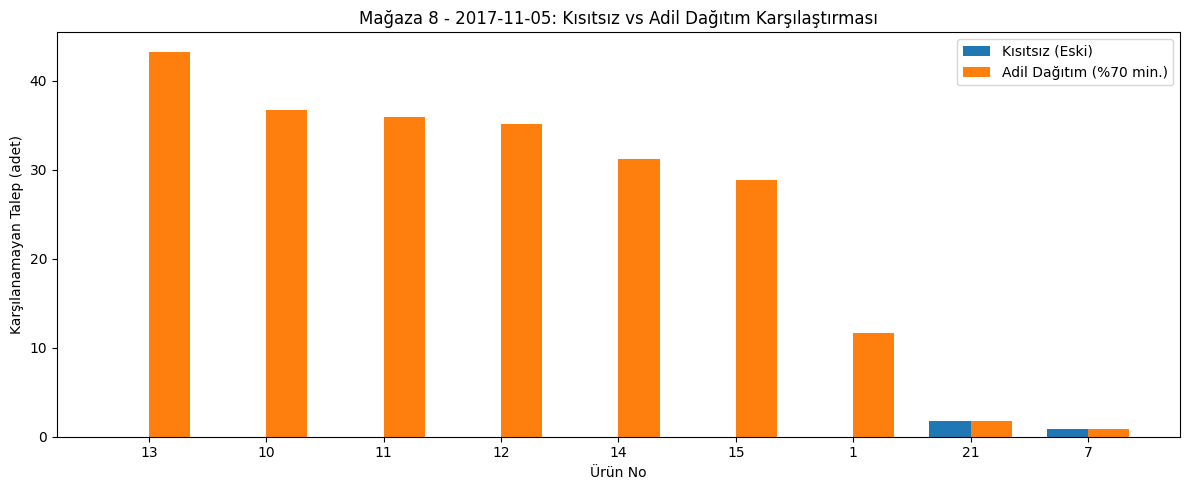

In [28]:
#En çok etkilenen 10 ürünü seçelim. (Adil modelde kesinti yaşyanlar)

top = scenario[scenario['unmet_fair'] > 0.1].sort_values('unmet_fair', ascending = False).head(10)

x_pos = range(len(top))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar([p - width/2 for p in x_pos], top['unmet'], width, label='Kısıtsız (Eski)')
plt.bar([p + width/2 for p in x_pos], top['unmet_fair'], width, label='Adil Dağıtım (%70 min.)')

plt.xticks(x_pos, top['item'].astype(str))
plt.xlabel('Ürün No')
plt.ylabel('Karşılanamayan Talep (adet)')
plt.title('Mağaza 8 - 2017-11-05: Kısıtsız vs Adil Dağıtım Karşılaştırması')
plt.legend()
plt.tight_layout()
plt.show()